# Decision Tree from Scratch

In this notebook, I'm implementing a Decision Tree from scratch using
NumPy. This one is different from what I did before no weights to
learn, no distances to compare. It just asks a bunch of yes/no questions
about the data to reach a prediction.

## What is a Decision Tree?

A Decision Tree works by asking a series of yes/no questions about the
data, until it reaches a final answer. Each question splits the data
into smaller groups, and this keeps happening until we're left with
groups that are (mostly) one single class.

Let's go back to our CGPA and placement example. Instead of using a
formula like Logistic Regression, or comparing distances like KNN, a
Decision Tree might ask something like this:

Is CGPA > 7.5?
- If Yes: Has done an internship?
  - If Yes: Placed
  - If No: Not Placed
- If No: Not Placed

So if a student has CGPA 8.5 and has done an internship, we just follow
the tree down: CGPA > 7.5? Yes. Internship? Yes. That leads us to
"Placed". If another student has CGPA 6.0, we go: CGPA > 7.5? No. That
directly leads to "Not Placed", without even checking internship status.

A few terms worth knowing here:
- **Root node** - the very first question at the top of the tree
- **Node** - any point in the tree where a question is being asked
- **Leaf node** - the final boxes where we actually get an answer
  (Placed / Not Placed), with no more questions after that
- **Branch** - the path connecting one node to the next, based on the
  answer (yes/no)

The tricky part is figuring out *which* question to ask at each step,
and *where* exactly to draw the line (like why CGPA > 7.5 and not 7.0 or
8.0). That's what the math in the next few sections is actually for.

## How Does the Tree Pick the Best Question?

The tree isn't just picking random questions to ask. It's trying to find
the question that splits the students into the "cleanest" possible
groups.

By clean, I mean something like this - if we split on "CGPA > 7.5" and
almost everyone above that got placed, and almost everyone below didn't,
that's a really good question. But if both sides end up with a random
mix of placed and not-placed students, that question isn't helping us
much.

So we need some way to actually measure how "mixed up" a group is. This
is where something called **impurity** comes in. There are two common
ways to calculate it - **Gini Impurity** and **Entropy**. We'll go
through both.

## Gini Impurity

Gini Impurity is just a way to measure how mixed up a group is. Here's
the formula:

$$Gini(S) = 1 - \sum_{i=1}^{K} p_i^2$$

$S$ is the group of samples we're looking at, $K$ is how many classes
there are, and $p_i$ is the fraction of each class in that group.

Let's just plug in some numbers to see how this works. Say we have 10
students - 8 placed, 2 not placed.

$$p_{placed} = 8/10 = 0.8, \quad p_{not\ placed} = 2/10 = 0.2$$

$$Gini(S) = 1 - (0.8^2 + 0.2^2) = 1 - 0.68 = 0.32$$

Now if the group was perfectly pure, say all 10 were placed:

$$Gini(S) = 1 - (1^2 + 0^2) = 0$$

So Gini = 0 means the group is fully pure, only one class in there. The
more mixed the group, the higher the number goes, maxing out at 0.5 when
it's a perfect 50-50 split.

## How Do We Actually Pick the Best Split?

Once we know how to measure impurity, we need a way to compare different
splits and figure out which one is actually good. That's what
Information Gain does:

$$IG(S,A) = Impurity(S) - \sum_{j} \frac{N_j}{N} \cdot Impurity(S_j)$$

$S$ is the data before we split it, $A$ is whatever feature we're
splitting on, $S_j$ is each smaller group after the split, $N_j$ is how
many samples are in that group, and $N$ is the total number of samples
before splitting.

Basically we're just taking the impurity before the split, and
subtracting the impurity after the split (averaged based on group size).
If a split does a good job separating placed vs not placed, the impurity
after will be small, so we end up subtracting a small number, which
means the gain is high.

To actually build the tree, we just try a bunch of splits, calculate the
gain for each, and go with whichever one gives the highest gain.

## When Does the Tree Stop Growing?

Here's a problem - if we let the tree keep asking questions forever, it
will eventually split the data so much that each tiny group has just one
or two students in it. At that point, the tree isn't really learning any
useful pattern anymore, it's basically just memorizing every single
student individually.

This causes a big issue called **overfitting**. The tree ends up doing
great on the training data (because it literally memorized it), but it
performs badly on any new student it hasn't seen before, since it never
actually learned a general rule.

So we need to tell the tree when to stop splitting. A few common ways to
do this are:

- **Max depth** - just limit how many questions deep the tree can go.
  For example, if max depth is 3, the tree can only ask 3 levels of
  questions before it has to stop and make a final decision.
- **Minimum samples to split** - don't allow the tree to split a group
  any further if it has too few samples left (like less than 5
  students). Splitting a tiny group doesn't really teach the model
  anything useful anyway.
- **Stop if already pure** - if a group's Gini impurity is already 0
  (meaning everyone in that group is the same class), there's no point
  splitting it further since there's nothing left to separate.

For our implementation, we'll keep it simple and just use a max depth
limit, since it's the easiest one to control and understand.

## Putting It All Together


1. Start with all the data at the top (this is the root)
2. Try out every possible split - every feature, every possible
   threshold value
3. For each one, calculate the information gain
4. Pick whichever split gave the highest gain
5. Split the data into two smaller groups based on that
6. Now do the exact same thing again, but separately for each of those
   two smaller groups
7. Keep repeating this until we hit a stopping point - either the group
   is already pure, or we've hit our max depth
8. Once we stop at a group, that becomes a leaf, and the prediction is
   just whatever class shows up the most in that group

When we want to predict something new, we just start at the root and
keep following the questions (yes/no) until we land on a leaf, and
that's our answer.

## Generating Data

For Decision Tree, I want to use a bit more than just CGPA, so the tree
actually gets to make some interesting multi-level splits. Adding two
more features: whether the student did an internship, and how many
projects they've done.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n_samples = 100

cgpa = 5 + 5 * np.random.rand(n_samples,1)
internship = np.random.randint(0,2,(n_samples,1))
projects = np.random.randint(0,6,(n_samples,1))

z = (cgpa - 7.5) + (internship * 1.5) + (projects * 0.3)
probability = 1/(1+np.exp(-z))
random_values = np.random.rand(n_samples,1)
placed = (probability > random_values).astype(int)

X = np.hstack((cgpa, internship, projects))

print(X[:5])
print(placed[:5])

[[6.87270059 0.         0.        ]
 [9.75357153 1.         0.        ]
 [8.65996971 0.         2.        ]
 [7.99329242 0.         5.        ]
 [5.7800932  1.         1.        ]]
[[1]
 [1]
 [1]
 [1]
 [1]]


In [2]:
print(placed.mean())
print(placed[cgpa.flatten() < 6].mean())
print(placed[cgpa.flatten() > 9].mean())

0.7
0.42857142857142855
0.9444444444444444


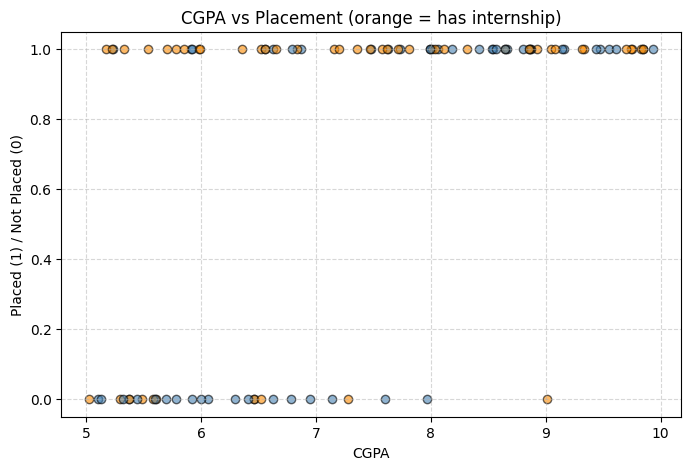

In [3]:
plt.figure(figsize=(8,5))

for i in range(len(cgpa)):
    if internship[i] == 1:
        plt.scatter(cgpa[i], placed[i], color="darkorange", alpha=0.6, edgecolor="k")
    else:
        plt.scatter(cgpa[i], placed[i], color="steelblue", alpha=0.6, edgecolor="k")

plt.xlabel("CGPA")
plt.ylabel("Placed (1) / Not Placed (0)")
plt.title("CGPA vs Placement (orange = has internship)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [4]:
from ml_from_scratch.base_model import BaseModel

class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf(self):
        return self.value is not None


def gini(y):
    classes = np.unique(y)
    impurity = 1
    for c in classes:
        p = np.sum(y == c) / len(y)
        impurity = impurity - p**2
    return impurity


def best_split(X, y):
    best_gain = -1
    best_feature = None
    best_threshold = None

    n_samples = X.shape[0]
    n_features = X.shape[1]
    parent_gini = gini(y)

    for feature in range(n_features):
        values = np.unique(X[:, feature])

        for threshold in values:
            left_side = X[:, feature] <= threshold
            right_side = X[:, feature] > threshold

            if len(y[left_side]) == 0 or len(y[right_side]) == 0:
                continue

            n_left = len(y[left_side])
            n_right = len(y[right_side])

            gini_left = gini(y[left_side])
            gini_right = gini(y[right_side])

            weighted_gini = (n_left/n_samples)*gini_left + (n_right/n_samples)*gini_right
            gain = parent_gini - weighted_gini

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain


def build_tree(X, y, depth=0, max_depth=5):
    n_classes = len(np.unique(y))

    if n_classes == 1 or depth >= max_depth or len(y) < 2:
        values, counts = np.unique(y, return_counts=True)
        leaf_value = values[np.argmax(counts)]
        return Node(value=leaf_value)

    feature, threshold, gain = best_split(X, y)

    if gain <= 0:
        values, counts = np.unique(y, return_counts=True)
        leaf_value = values[np.argmax(counts)]
        return Node(value=leaf_value)

    left_side = X[:, feature] <= threshold
    right_side = X[:, feature] > threshold

    left_child = build_tree(X[left_side], y[left_side], depth+1, max_depth)
    right_child = build_tree(X[right_side], y[right_side], depth+1, max_depth)

    return Node(feature=feature, threshold=threshold, left=left_child, right=right_child)


class DecisionTree(BaseModel):

    def __init__(self, max_depth=5):
        super().__init__()
        self.max_depth = max_depth
        self.root = None

    def fit(self, X, y):
        y = y.flatten()
        self.root = build_tree(X, y, 0, self.max_depth)
        self.is_fitted = True
        return self

    def predict_single(self, x, node):
        if node.is_leaf():
            return node.value
        if x[node.feature] <= node.threshold:
            return self.predict_single(x, node.left)
        else:
            return self.predict_single(x, node.right)

    def predict(self, X):
        self._check_is_fitted()
        predictions = []
        for x in X:
            pred = self.predict_single(x, self.root)
            predictions.append(pred)
        return np.array(predictions)

In [5]:
model = DecisionTree(max_depth=5)
model.fit(X, placed)

predictions = model.predict(X)
print(predictions[:10])

[1 1 1 1 1 0 1 1 1 1]


In [6]:
print(predictions.mean())
print(placed.flatten().mean())

0.75
0.7


In [7]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(placed, predictions)
precision = precision_score(placed, predictions)
recall = recall_score(placed, predictions)
conf_matrix = confusion_matrix(placed, predictions)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("Confusion Matrix:\n", conf_matrix)

Accuracy: 0.93
Precision: 0.92
Recall: 0.9857142857142858
Confusion Matrix:
 [[24  6]
 [ 1 69]]


In [8]:
model_shallow = DecisionTree(max_depth=2)
model_shallow.fit(X, placed)
predictions_shallow = model_shallow.predict(X)

accuracy_shallow = accuracy_score(placed, predictions_shallow)
print("Shallow Tree Accuracy:", accuracy_shallow)

Shallow Tree Accuracy: 0.81


## Wait, Why Is Accuracy So High?

When I first trained the tree with max_depth=5, I got 93% accuracy, which
felt way too good compared to the other algorithms (Logistic Regression
and KNN were both around 78-80% on similar data).

Turns out this is overfitting. With max_depth=5, the tree can keep
splitting the data into really specific, tiny groups, to the point where
it basically starts memorizing individual students instead of learning
a general pattern especially since I'm testing on the same data I
trained on.

To check this, I tried max_depth=2 instead, and accuracy dropped to 81%.
That's a big enough drop to confirm the deeper tree was overfitting. A
shallow tree can't create those overly specific splits, so it's forced
to stick to more general, useful patterns which also happens to line
up nicely with the accuracy from Logistic Regression and KNN.

In [9]:
from sklearn.tree import DecisionTreeClassifier

sklearn_model = DecisionTreeClassifier(max_depth=2, criterion="gini")
sklearn_model.fit(X, placed.ravel())
sklearn_predictions = sklearn_model.predict(X)

sklearn_accuracy = accuracy_score(placed, sklearn_predictions)
print("Sklearn Accuracy:", sklearn_accuracy)

Sklearn Accuracy: 0.81


## Conclusion

Decision Tree feels pretty different from everything covered before. No
weights, no distances, no gradients it's just a bunch of yes/no
questions stacked on top of each other, and each question tries to split
the data as cleanly as possible.

The new concepts here are Gini Impurity for measuring how mixed a group
is, Information Gain for picking the best split, and recursion for
actually building the tree (the build_tree function calling itself on
smaller pieces of data can feel a bit confusing at first).

One of the most important things to notice here is overfitting. With
max_depth=5, the tree gives 93% accuracy, which looks great but is
actually just memorizing the training data. Dropping to max_depth=2
gives a more honest 81%, which also lines up with what Logistic
Regression and KNN got on similar data.

Results matched scikit-learn's implementation exactly at max_depth=2, so
the logic here checks out.